# Detección Adaptativa de Carriles en Condiciones de Iluminación Variable
## Seguimiento 2: Primera versión de la implementación

**Grupo 9:** Hugo Toro Meca, Miguel García Losada, Daniel Salamanca Garrido

---

### Resumen del Notebook
Este cuaderno presenta la implementación práctica del sistema de visión por computador detallado en el artículo *"Robust Lane Detection under Varying Lighting Conditions Using Adaptive Vision-Based Techniques"* .

El objetivo de este documento es construir y explicar de forma didáctica un *pipeline* algorítmico capaz de detectar las líneas de la carretera, ajustando dinámicamente sus técnicas de procesamiento según el nivel de luz del entorno desarrollando paso a paso el uso de filtros morfológicos, enmascaramiento espacial y transformadas geométricas .

A lo largo del cuaderno definiremos las funciones matemáticas requeridas, justificaremos los parámetros elegidos y visualizaremos los resultados intermedios de los algoritmos (Canny, Hough y HSV) para evaluar su robustez.

### 1. Importación de Librerías y Preparación del Entorno

Para implementar el sistema propuesto en el artículo y poder procesar las imágenes de nuestra base de datos, nos apoyaremos en las siguientes librerías estándar de Python:

* **OpenCV (`cv2`)**: Es el motor principal de visión por computador de nuestro trabajo. Nos proporciona las implementaciones optimizadas de los algoritmos clásicos que necesitamos, como las conversiones de espacio de color (Grises, HSV), los filtros espaciales (Desenfoque Gaussiano, Canny) y las transformadas geométricas (Transformada de Hough).
* **NumPy (`np`)**: Es fundamental para el cálculo numérico. En Python, las imágenes se procesan como matrices multidimensionales. NumPy nos permite aplicar operaciones matemáticas rápidas sobre estas matrices, como el cálculo de la media para el detector de brillo o el promediado geométrico de las pendientes de los carriles.
* **Matplotlib (`plt`)**: Será nuestra herramienta de visualización didáctica. La usaremos para incrustar las imágenes resultantes y renderizar los pasos intermedios de las máscaras directamente en este cuaderno.
* **OS**: Una librería del sistema necesaria para interactuar con las rutas de los archivos, lo que nos permitirá automatizar la lectura de los miles de fotogramas secuenciales de nuestra base de datos.
* **Math**: Proporciona operaciones matemáticas estándar. La utilizaremos para calcular el logaritmo en base 10 exigido matemáticamente por la fórmula de la Corrección Gamma adaptativa.

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random

## 2. Definición de Variables Globales y Carga de Datos

Para evaluar empíricamente la robustez de nuestro algoritmo frente a distintas condiciones de iluminación, utilizaremos dos bases de datos (datasets) estándar en la industria de la conducción autónoma. Dado que cada base de datos tiene una estructura de archivos diferente, hemos diseñado funciones de carga independientes:

* **Dataset TuSimple (Secuencias Cortas):** Su estructura se basa en múltiples subcarpetas, donde cada una representa un clip de vídeo corto (aprox. 20 fotogramas cronológicos). Es ideal para evaluar la *consistencia temporal* de nuestro algoritmo y comprobar si las líneas "parpadean" entre un fotograma y el siguiente.
* **Dataset Udacity (Test de Estrés):** Consiste en un único directorio masivo con decenas de miles de fotogramas (aprox. 28.000 imágenes). Lo utilizaremos como banco de pruebas principal para someter al sistema a un test de estrés prolongado frente a cambios drásticos de iluminación (sombras densas, destellos, transición día/noche). 

Para evitar problemas de desbordamiento de memoria (RAM) al procesar la base de datos de Udacity en este entorno interactivo, la función de carga incorpora un parámetro limitador (`max_frames`) que nos permitirá extraer y procesar solo los segmentos que necesitemos para cada prueba.

In [3]:
# Cambiar por la ruta donde tengamos nustra BD
RUTA_TUSIMPLE = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD1\TUSimple\test_set\clips\0530" #Tres subcarpetas: 0530, 0531, 0601
RUTA_NOCTURNA = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD2"                    #BD Imagnes Nocturnas
RUTA_UDACITY = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD3\data\export"                   #BD Prueba de Estres

In [5]:
def cargar_secuencia_tusimple(ruta_base):
    """
    Lee la estructura de subcarpetas anidadas de TuSimple.
    Elige un clip de vídeo al azar y devuelve sus fotogramas ordenados cronológicamente.
    """
    carpetas_videos = [os.path.join(ruta_base, d) for d in os.listdir(ruta_base) 
                       if os.path.isdir(os.path.join(ruta_base, d))]
    
    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas de vídeo en la ruta de TuSimple.")
        return []
        
    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)
    
    fotogramas = sorted([os.path.join(carpeta_elegida, f) for f in os.listdir(carpeta_elegida) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    print(f"TuSimple cargado: Seleccionado clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas

def cargar_secuencia_bd2_nocturna(ruta_base):
    """
    Lee la estructura de subcarpetas de la BD2 (Nocturna).
    Elige un clip de vídeo al azar y devuelve sus fotogramas ordenados cronológicamente.
    """
    carpetas_videos = [os.path.join(ruta_base, d) for d in os.listdir(ruta_base) 
                       if os.path.isdir(os.path.join(ruta_base, d))]
    
    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas de vídeo en la ruta de BD2.")
        return []
        
    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)
    
    fotogramas = sorted([os.path.join(carpeta_elegida, f) for f in os.listdir(carpeta_elegida) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    print(f"BD2 Nocturna cargada: Seleccionado clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas


def cargar_secuencia_udacity(ruta_base, max_frames=300):
    """
    Lee la estructura plana de Udacity (un directorio masivo).
    Devuelve los fotogramas ordenados, limitados a 'max_frames' para evitar colapsos de RAM.
    """
    fotogramas = sorted([os.path.join(ruta_base, f) for f in os.listdir(ruta_base) 
                         if f.endswith('.jpg') or f.endswith('.png')])
                         
    total_disponibles = len(fotogramas)
    
    if total_disponibles == 0:
        print("Error: No se encontraron imágenes en la ruta de Udacity.")
        return []
        
    fotogramas_recortados = fotogramas[:max_frames]
    print(f"Udacity cargado: Extraídos {len(fotogramas_recortados)} fotogramas (de {total_disponibles} disponibles).")
    return fotogramas_recortados



# ==========================================
# EJEMPLO DE USO (Descomenta el que quieras usar)
# ==========================================
# Seleccionamos con qué dataset queremos que trabaje el cuaderno a partir de este punto:

#fotogramas_a_procesar = cargar_secuencia_tusimple(RUTA_TUSIMPLE)
fotogramas_a_procesar = cargar_secuencia_bd2_nocturna(RUTA_NOCTURNA)
# fotogramas_a_procesar = cargar_secuencia_udacity(RUTA_UDACITY, max_frames=500)


BD2 Nocturna cargada: Seleccionado clip 'clip_069' con 20 fotogramas.


**Comprobación visual del Dataset:** Para asegurarnos de que las rutas son correctas y las imágenes se han indexado adecuadamente, extraemos y visualizamos 4 fotogramas aleatorios del dataset que acabamos de cargar en memoria.

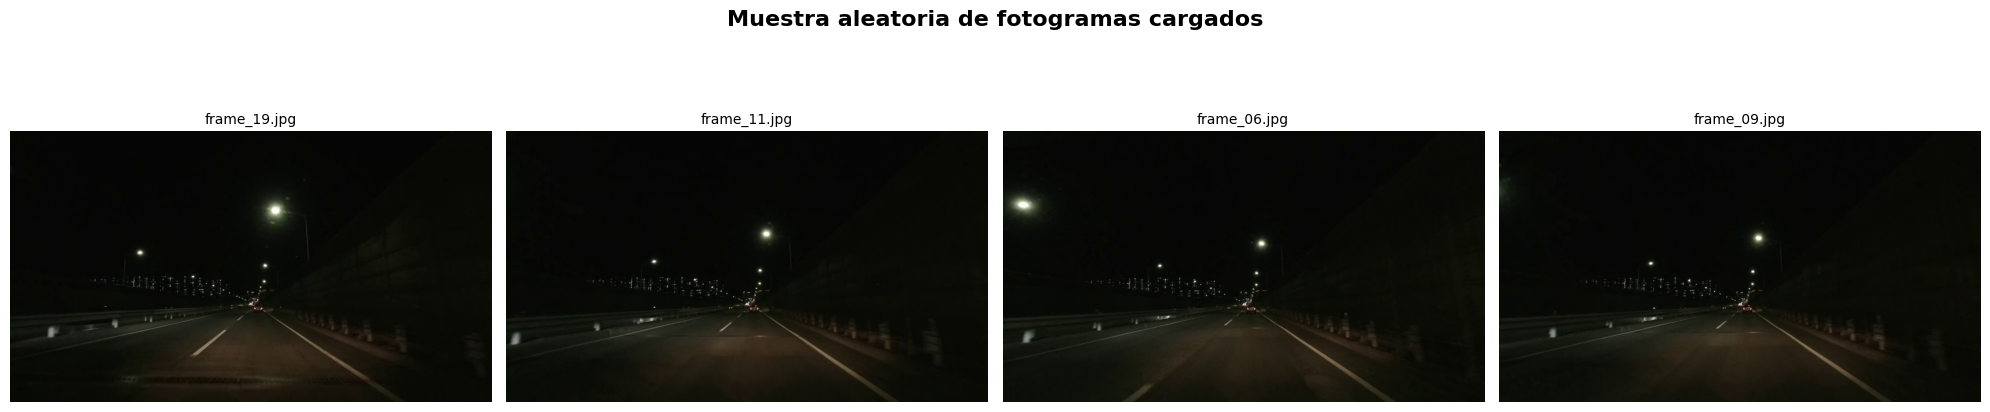

In [7]:


# Verificamos que la variable del dataset existe y tiene datos
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    
    # Elegimos 4 imágenes al azar (o menos, si el dataset fuera más pequeño)
    num_muestras = min(4, len(fotogramas_a_procesar))
    muestras = random.sample(fotogramas_a_procesar, num_muestras)
    
    # Preparamos una figura con 4 columnas
    fig, axs = plt.subplots(1, num_muestras, figsize=(20, 5))
    fig.suptitle("Muestra aleatoria de fotogramas cargados", fontsize=16, fontweight='bold')
    
    # Si solo hay 1 imagen, axs no es un array, lo convertimos para evitar errores
    if num_muestras == 1: axs = [axs]
        
    for i, ruta in enumerate(muestras):
        img = cv2.imread(ruta)
        if img is not None:
            # Pasamos a RGB para que Matplotlib no cambie los colores
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
            axs[i].imshow(img_rgb)
            
            # Mostramos el nombre del archivo como título de la foto
            nombre_archivo = os.path.basename(ruta)
            axs[i].set_title(nombre_archivo, fontsize=10)
            
        axs[i].axis('off') # Quitamos los ejes numéricos para que quede más limpio
        
    plt.tight_layout()
    plt.show()
    
else:
    print("¡Aviso! No se han detectado fotogramas. Asegúrate de ejecutar la celda anterior y descomentar uno de los datasets.")

## 3. Clasificador Dinámico de Iluminación (Día/Noche)

La principal contribución del artículo de referencia es la adaptabilidad del algoritmo frente a los cambios ambientales. Para lograrlo, el sistema debe ser capaz de evaluar la cantidad de luz de un fotograma en tiempo real y decidir qué ruta de procesamiento (*pipeline*) tomar.

Según se detalla en la sección 3.4 del artículo, este proceso se realiza analizando la intensidad lumínica global de la imagen. El algoritmo sigue estos pasos matemáticos exactos:

**1. Conversión al espacio de color Grises:**
La imagen original se transforma a escala de grises para aislar la información de intensidad lumínica (descartando la saturación y el tono).

**2. Cálculo del Brillo Medio (Ecuación 37):**
Se calcula la media aritmética de las intensidades de todos los píxeles de la imagen. Matemáticamente, el brillo promedio $B$ se define como:

$$B = \frac{1}{M \times N} \sum_{i=1}^{M} \sum_{j=1}^{N} I_{gray}(i,j)$$

Donde:
* $M$ y $N$ representan el alto y el ancho de la imagen (dimensiones de la matriz).
* $I_{gray}(i,j)$ es el valor de intensidad (de 0 a 255) del píxel en la coordenada $(i,j)$.

**3. Decisión mediante Umbralización (Ecuación 38):**
Una vez obtenido el brillo medio $B$, se evalúa contra un umbral predefinido $T$. Los autores del artículo establecen empíricamente que **$T = 50$**. La función de clasificación $F(B)$ se define como:

$$ 
F(B) = 
\begin{cases} 
1 & \text{si } B > 50 \implies \text{MODO DÍA} \\
0 & \text{si } B \leq 50 \implies \text{MODO NOCHE} 
\end{cases}
$$

A continuación, implementamos este modelo matemático aprovechando la función `np.mean()` de NumPy, la cual realiza la sumatoria y división de la matriz de forma altamente optimizada.

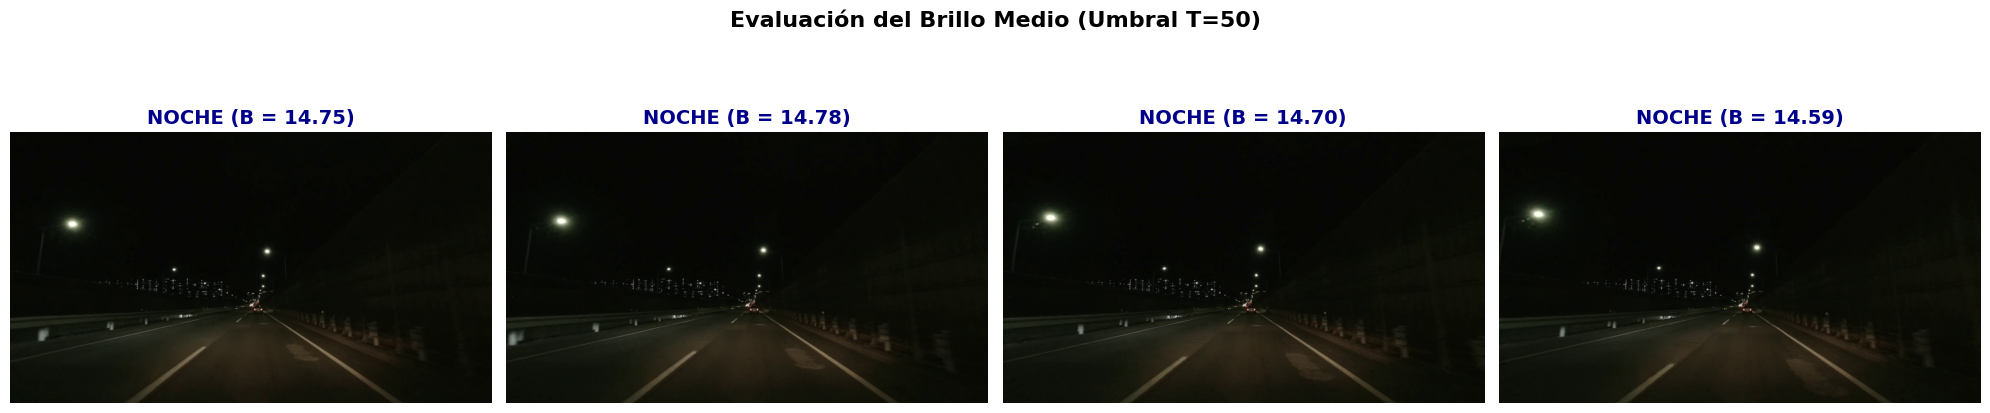

In [8]:
# ==========================================
# 3. IMPLEMENTACIÓN DEL CLASIFICADOR DE LUZ
# ==========================================

def evaluar_iluminacion(imagen, umbral=50):
    """
    Implementa la Ec. 37 y 38 del artículo para clasificar el fotograma.
    
    Parámetros:
        imagen: Matriz numpy (fotograma BGR cargado con OpenCV).
        umbral: Valor de decisión (T=50 según el artículo).
        
    Retorna:
        imagen_gris: La imagen convertida a escala de grises.
        brillo_medio: El valor flotante exacto de B.
        modo: String ("DÍA" o "NOCHE").
    """
    
    # 1. Transformación a Grises (I_gray)
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # 2. Cálculo del brillo promedio B (sumatoria / (M x N))
    # np.mean es matemáticamente equivalente a la Ecuación 37
    brillo_medio = np.mean(imagen_gris)
    
    # 3. Regla de decisión lógica (Ecuación 38)
    if brillo_medio > umbral:
        modo = "DÍA"
    else:
        modo = "NOCHE"
        
    return imagen_gris, brillo_medio, modo


# --- COMPROBACIÓN DEL CLASIFICADOR ---
# Vamos a evaluar las primeras 4 imágenes cargadas en la variable global
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    
    # Cogemos 4 imágenes en orden para ver cómo cambia la secuencia
    imagenes_test = fotogramas_a_procesar[:4]
    
    fig, axs = plt.subplots(1, len(imagenes_test), figsize=(20, 5))
    fig.suptitle("Evaluación del Brillo Medio (Umbral T=50)", fontsize=16, fontweight='bold')
    
    if len(imagenes_test) == 1: axs = [axs]
        
    for i, ruta in enumerate(imagenes_test):
        img_bgr = cv2.imread(ruta)
        
        # Ejecutamos nuestra función matemática
        img_gris, B, modo = evaluar_iluminacion(img_bgr)
        
        # Mostramos la imagen en RGB para apreciar mejor la luz real
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img_rgb)
        
        # Color del título según el modo
        color = 'darkorange' if modo == "DÍA" else 'darkblue'
        axs[i].set_title(f"{modo} (B = {B:.2f})", fontsize=14, color=color, fontweight='bold')
        axs[i].axis('off')
        
    plt.tight_layout()
    plt.show()

## 4. Pipeline del Modo Día: Detección y Preprocesamiento

Siguiendo estrictamente la metodología del artículo, la detección de carriles diurna comienza con un proceso de simplificación visual basado en el color y filtros espaciales. 

### 4.1. Filtro de Color, Escala de Grises y Suavizado
El primer paso consiste en aislar las marcas viales. Como indican los autores: *"After colour selection, the image is converted to grayscale to simplify the image. Gaussian blur is further applied to reduce noise and smooth the image"*.

1. **Selección de color (HSV):** Filtramos los rangos de amarillo y blanco.
2. **Escala de grises:** Reducimos la dimensionalidad de la imagen.
3. **Desenfoque Gaussiano:** Suavizamos las texturas del asfalto para evitar falsos positivos en la posterior detección de bordes.

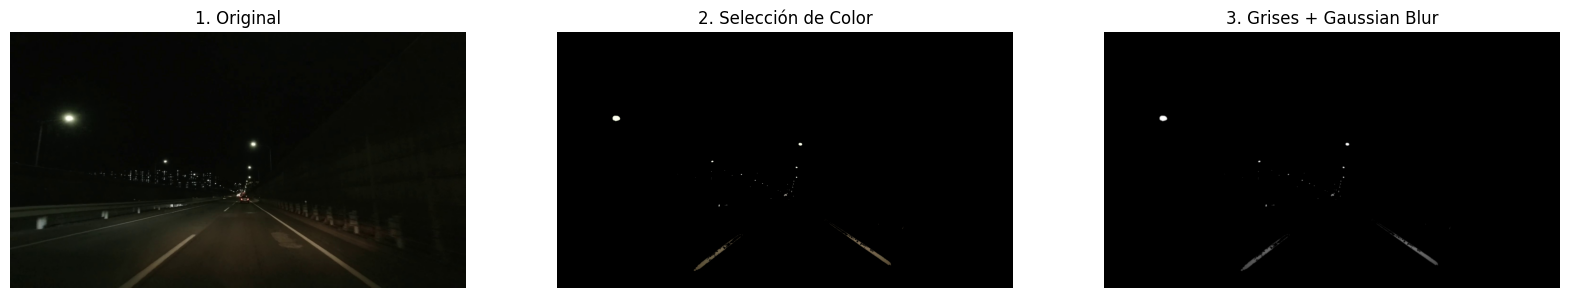

In [9]:
# ==========================================
# 4.1. FILTRO DE COLOR + GRISES + GAUSSIANO
# ==========================================

if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    ruta_prueba_dia = fotogramas_a_procesar[0]
    img_dia = cv2.imread(ruta_prueba_dia)
    img_dia_rgb = cv2.cvtColor(img_dia, cv2.COLOR_BGR2RGB)
    
    # 1. Filtro de Color (HSV)
    hsv = cv2.cvtColor(img_dia, cv2.COLOR_BGR2HSV)
    mascara_amarillo = cv2.inRange(hsv, np.array([15, 80, 80]), np.array([35, 255, 255]))
    mascara_blanco = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 30, 255]))
    mascara_color = cv2.bitwise_or(mascara_amarillo, mascara_blanco)
    
    img_filtrada_color = cv2.bitwise_and(img_dia, img_dia, mask=mascara_color)
    
    # 2. Conversión a Escala de Grises
    img_gris = cv2.cvtColor(img_filtrada_color, cv2.COLOR_BGR2GRAY)
    
    # 3. Suavizado Gaussiano
    img_blur = cv2.GaussianBlur(img_gris, (5, 5), 0)
    
    # Visualización
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    axs[0].imshow(img_dia_rgb)
    axs[0].set_title("1. Original")
    axs[1].imshow(img_filtrada_color[:,:,::-1]) 
    axs[1].set_title("2. Selección de Color")
    axs[2].imshow(img_blur, cmap='gray')
    axs[2].set_title("3. Grises + Gaussian Blur")
    for ax in axs: ax.axis('off')
    plt.show()
else:
    print("Carga primero el dataset en la sección 2.")

### 4.2. Detección de Bordes y Región de Interés (ROI)

Una vez simplificada la imagen, procedemos a la extracción de las características geométricas. 
Según el artículo: *"Lane line detection begins with edge detection using the Canny edge detector. It highlights edges in an image by analysing gradient magnitudes and directions"*.

Tras calcular este mapa de gradientes binario, aplicamos una **Máscara Poligonal (ROI)**. Matemáticamente y a nivel de código, es vital aplicar la máscara *después* de Canny. Si recortáramos la imagen antes, el filtro de Canny detectaría los bordes artificiales del propio trapecio negro, arruinando la detección.

Para garantizar la robustez del sistema frente a vibraciones o desplazamientos laterales de la cámara del vehículo, hemos parametrizado un ROI ensanchado en su límite superior (abarcando el 30% central del horizonte) que asegure la captura de las líneas de fuga incluso en curvas suaves.

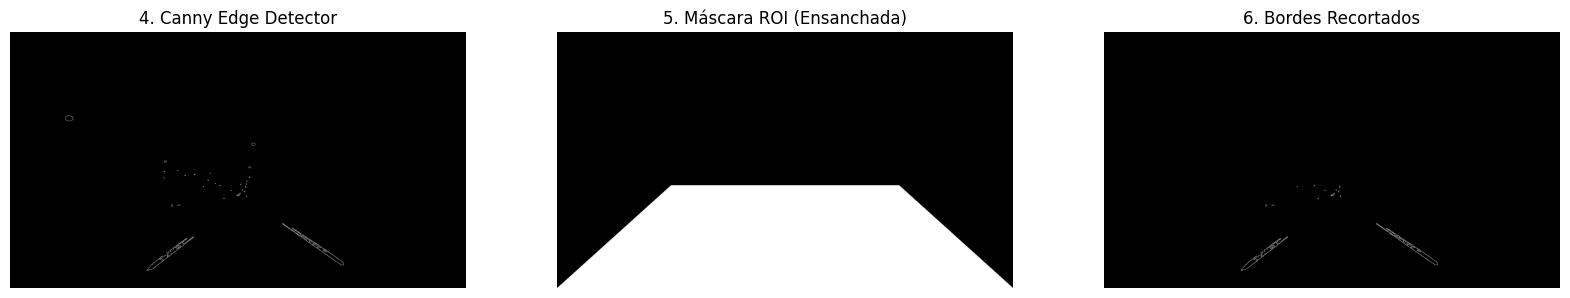

In [10]:
# ==========================================
# 4.2. CANNY EDGE DETECTOR + ROI MASK
# ==========================================

# 1. Filtro de Canny (Analiza magnitudes de gradiente)
# Usamos los umbrales estándar (50, 150) para la histéresis
img_canny = cv2.Canny(img_blur, 50, 150)

# 2. Creación de la Máscara Poligonal (ROI) Ampliada
alto, ancho = img_canny.shape

# Definimos los 4 vértices del trapecio de forma dinámica
# Ensanchamos la parte superior para atrapar las líneas si la cámara está descentrada
poligono_roi = np.array([[
    (0, alto),                                 # Esquina inferior izquierda
    (ancho, alto),                             # Esquina inferior derecha
    (int(ancho * 0.75), int(alto * 0.6)),      # Vértice superior derecho (Ampliado al 75%)
    (int(ancho * 0.25), int(alto * 0.6))       # Vértice superior izquierdo (Ampliado al 25%)
]])

mascara_roi = np.zeros_like(img_canny)
cv2.fillPoly(mascara_roi, poligono_roi, 255)

# 3. Aplicar el recorte sobre el mapa de bordes
img_roi = cv2.bitwise_and(img_canny, mascara_roi)

# Visualización
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(img_canny, cmap='gray')
axs[0].set_title("4. Canny Edge Detector")
axs[1].imshow(mascara_roi, cmap='gray')
axs[1].set_title("5. Máscara ROI (Ensanchada)")
axs[2].imshow(img_roi, cmap='gray')
axs[2].set_title("6. Bordes Recortados")
for ax in axs: ax.axis('off')
plt.show()

### 4.3. Transformada de Hough y Promediado de Líneas (Lane Line Averaging)

El último paso es convertir los píxeles blancos del mapa de bordes en entidades matemáticas. El artículo establece: *"Once the edges are detected, Hough Transform is applied to detect lane lines. This method transforms edge points into a parameter space to identify straight-line segments"*. 

La ecuación fundamental en el espacio de Hough está dada por:
$$\rho = x\cos\theta + y\sin\theta$$

Tras extraer los múltiples segmentos detectados por Hough, aplicamos el proceso de **Lane Line Averaging** para unificarlos en dos únicos límites estables. Utilizando los extremos $(x_1, y_1)$ y $(x_2, y_2)$ de cada segmento, calculamos la pendiente (Eq. 9) y la intersección (Eq. 10):

$$slope = \frac{y_2 - y_1}{x_2 - x_1}$$
$$intercept = y_1 - slope \cdot x_1$$

Finalmente, promediamos estos valores para trazar las líneas delimitadoras finales.

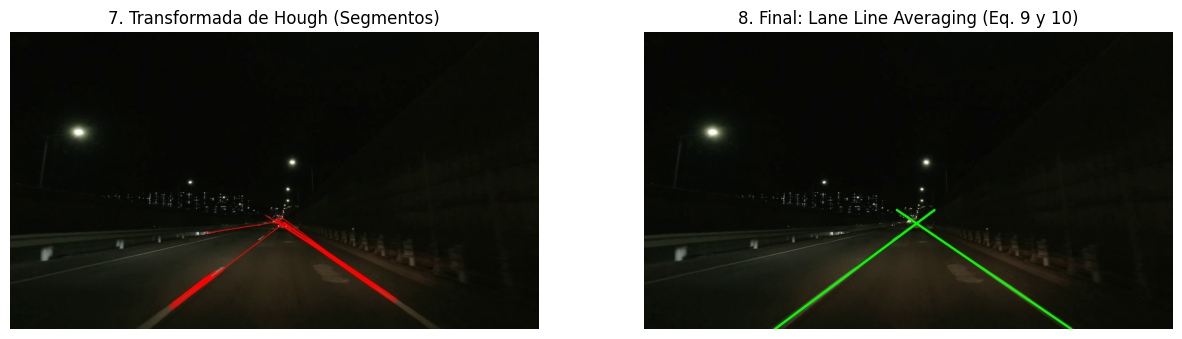

In [11]:
# ==========================================
# 4.3. HOUGH TRANSFORM & LINE AVERAGING
# ==========================================

# 1. Transformada de Hough
lineas_hough = cv2.HoughLinesP(img_roi, rho=1, theta=np.pi/180, threshold=20, 
                               minLineLength=20, maxLineGap=300)

img_hough_bruto = np.copy(img_dia_rgb)
img_resultado_final = np.copy(img_dia_rgb)

pendientes_izq, interceptos_izq = [], []
pendientes_der, interceptos_der = [], []

if lineas_hough is not None:
    for linea in lineas_hough:
        x1, y1, x2, y2 = linea[0]
        
        # Dibujamos las líneas sueltas de Hough para visualización (rojo)
        cv2.line(img_hough_bruto, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        if x1 == x2: continue # Evitar divisiones por cero
            
        # 2. Aplicación de las Ecuaciones 9 y 10 (Slope e Intercept)
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        
        # Filtrado de líneas horizontales y clasificación en izquierda/derecha
        if slope < -0.5:
            pendientes_izq.append(slope)
            interceptos_izq.append(intercept)
        elif slope > 0.5:
            pendientes_der.append(slope)
            interceptos_der.append(intercept)

# 3. Promediado (Lane Line Averaging)
y_max = img_resultado_final.shape[0]
y_min = int(y_max * 0.6)

def dibujar_carril_promediado(pendientes, interceptos, color):
    if len(pendientes) > 0:
        # Calculamos el average slope e intercept
        avg_slope = np.mean(pendientes)
        avg_intercept = np.mean(interceptos)
        
        # Invertimos la fórmula para hallar las X finales: x = (y - intercept) / slope
        x_fondo = int((y_min - avg_intercept) / avg_slope)
        x_base = int((y_max - avg_intercept) / avg_slope)
        
        cv2.line(img_resultado_final, (x_fondo, y_min), (x_base, y_max), color, 8)

# Dibujamos las líneas promediadas finales
dibujar_carril_promediado(pendientes_izq, interceptos_izq, (0, 255, 0)) # Verde
dibujar_carril_promediado(pendientes_der, interceptos_der, (0, 255, 0)) # Verde

# Visualización
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].imshow(img_hough_bruto)
axs[0].set_title("7. Transformada de Hough (Segmentos)")
axs[1].imshow(img_resultado_final)
axs[1].set_title("8. Final: Lane Line Averaging (Eq. 9 y 10)")
for ax in axs: ax.axis('off')
plt.show()

## 5. Pipeline del Modo Noche: Mejora de Visibilidad y Filtrado HSV

La detección nocturna es el componente más crítico del sistema. Debido a la baja luminancia, los bordes detectados por Canny suelen ser ruidosos o inexistentes. Por ello, el método propuesto introduce una etapa de preprocesamiento no lineal para realzar las características del carril.

### 5.1. Corrección Gamma Adaptativa
Para mejorar la visibilidad en condiciones de poca luz, se aplica una corrección Gamma dinámica. El valor de $\gamma$ se ajusta automáticamente según el brillo promedio del fotograma ($Y_{average}$), siguiendo las ecuaciones 18 del artículo:

$$\gamma_{base} = \frac{-0.3}{\log_{10}(Y_{average} + \epsilon)}$$
$$\gamma_{final} = 0.7 - \gamma_{base}$$

Esta transformación expande los niveles de gris en las zonas oscuras, permitiendo que las líneas de la carretera sean perceptibles para los algoritmos posteriores.

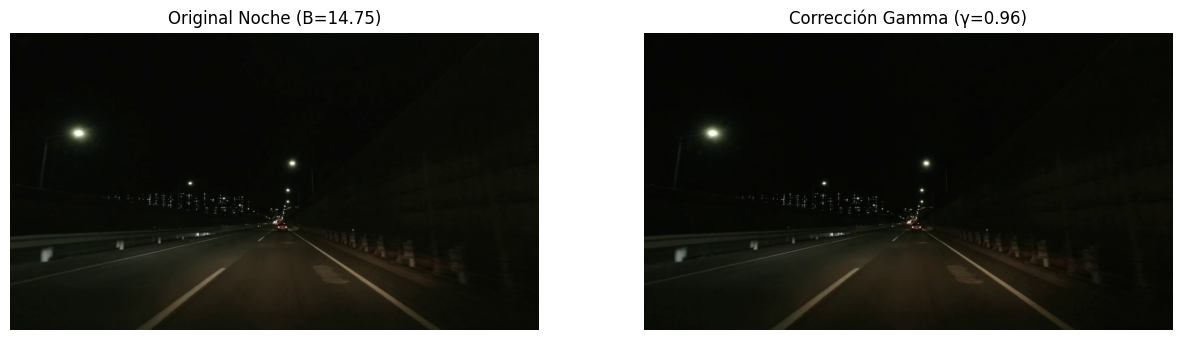

In [12]:
# ==========================================
# 5.1. CORRECCIÓN GAMMA ADAPTATIVA (Eq. 18)
# ==========================================

if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    # Seleccionamos un fotograma de la BD nocturna
    ruta_noche = fotogramas_a_procesar[0]
    img_noche = cv2.imread(ruta_noche)
    img_noche_rgb = cv2.cvtColor(img_noche, cv2.COLOR_BGR2RGB)
    
    # 1. Calculamos brillo promedio (Y_average)
    gris_noche = cv2.cvtColor(img_noche, cv2.COLOR_BGR2GRAY)
    y_average = np.mean(gris_noche)
    
    # 2. Aplicamos fórmulas del artículo (Eq. 18)
    epsilon = 1e-6
    gamma_base = -0.3 / math.log10(y_average + epsilon)
    gamma_final = 0.7 - gamma_base
    
    # 3. Aplicar la corrección mediante una tabla de búsqueda (LUT)
    inv_gamma = 1.0 / gamma_final
    tabla = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv2.LUT(img_noche, tabla)
    
    # Visualización
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].imshow(img_noche_rgb)
    axs[0].set_title(f"Original Noche (B={y_average:.2f})")
    axs[1].imshow(cv2.cvtColor(img_gamma, cv2.COLOR_BGR2RGB))
    axs[1].set_title(f"Corrección Gamma (γ={gamma_final:.2f})")
    for ax in axs: ax.axis('off')
    plt.show()

### 5.2. Filtrado de Color en Espacio HSV
Tras mejorar la iluminación, el sistema utiliza el espacio de color HSV para aislar los carriles. A diferencia del RGB, el espacio HSV separa la luminancia de la información cromática, siendo más robusto a los destellos de los faros. 

Se aplican filtros binarios para extraer los píxeles amarillos y blancos (Ecuaciones 19 a 22):

$$mask = mask_{yellow} \lor mask_{white}$$
$$I_{filtered} = I_{RGB} \cdot mask$$

Este proceso genera un mapa binario donde solo permanecen los elementos con alta probabilidad de ser marcas viales.

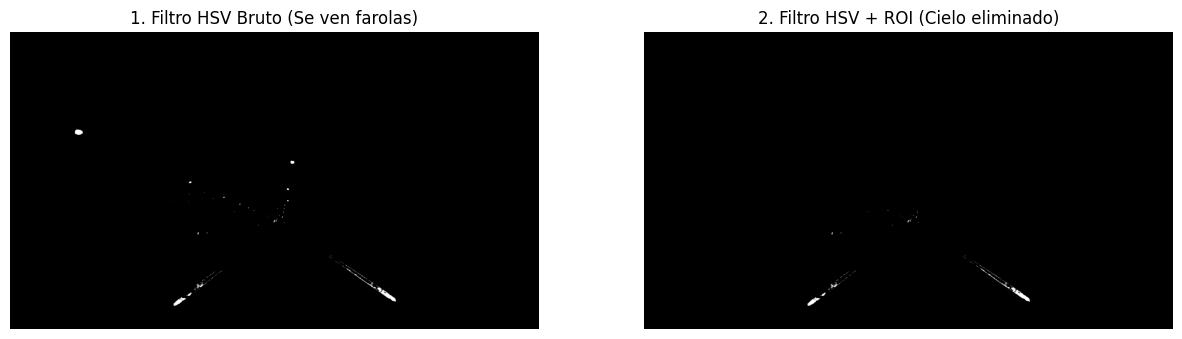

In [13]:
# ==========================================
# 5.2. FILTRADO HSV ESTRICTO (Eq. 19 a 23)
# ==========================================

hsv_noche = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2HSV)

# AJUSTE EMPÍRICO: Hemos endurecido los umbrales respecto a la teoría básica
# para rechazar el ruido lumínico urbano (farolas y reflejos).

# Blanco: Exigimos muchísima luminosidad (Valor > 200) y casi nula saturación (Sat < 25)
rango_bajo_blanco = np.array([0, 0, 200])
rango_alto_blanco = np.array([180, 25, 255])

# Amarillo: Exigimos alta saturación (Sat > 90) para ignorar el halo difuso de las farolas
rango_bajo_amarillo = np.array([15, 90, 80])
rango_alto_amarillo = np.array([35, 255, 255])

mask_white = cv2.inRange(hsv_noche, rango_bajo_blanco, rango_alto_blanco)
mask_yellow = cv2.inRange(hsv_noche, rango_bajo_amarillo, rango_alto_amarillo)

# Unión lógica (Eq. 22 y 23)
mascara_total = cv2.bitwise_or(mask_white, mask_yellow)

# Aplicamos la máscara ROI aquí mismo para limpiar el cielo de inmediato
alto, ancho = mascara_total.shape
poligono_noche = np.array([[(0, alto), (ancho, alto), 
                            (int(ancho * 0.75), int(alto * 0.6)), 
                            (int(ancho * 0.25), int(alto * 0.6))]])
mask_roi_visual = np.zeros_like(mascara_total)
cv2.fillPoly(mask_roi_visual, poligono_noche, 255)

# La imagen final filtrada sin cielo ni farolas altas
mascara_limpia = cv2.bitwise_and(mascara_total, mask_roi_visual)
img_final_hsv = cv2.bitwise_and(img_gamma, img_gamma, mask=mascara_limpia)

# Visualización
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(mascara_total, cmap='gray')
axs[0].set_title("1. Filtro HSV Bruto (Se ven farolas)")
axs[1].imshow(mascara_limpia, cmap='gray')
axs[1].set_title("2. Filtro HSV + ROI (Cielo eliminado)")
for ax in axs: ax.axis('off')
plt.show()

### 5.3. Identificación de Límites y Escalado (Lane Boundary Detection)

Una vez que la Transformada de Hough Probabilística (PHT) detecta los múltiples segmentos en la imagen nocturna, debemos filtrar y seleccionar los carriles reales. Siguiendo el texto del artículo: *"Lane boundaries are identified by selecting the two closest lines to the frame centre"*.

Para cada línea detectada, aplicamos las Ecuaciones 12, 13 y 14:
1. **Orientación ($\theta$):** Filtramos líneas horizontales mediante $\theta = |\arctan(\frac{y_2-y_1}{x_2-x_1})|$.
2. **Punto Medio ($x_m$):** Calculamos el centro del segmento $x_m = \frac{x_1-x_2}{2}$ (en la implementación práctica usamos suma para evitar coordenadas negativas relativas).
3. **Distancia al centro ($d$):** Calculamos $d = |x_m - x_c|$.

Separamos las líneas en izquierda y derecha según la dirección de su pendiente, y seleccionamos **estrictamente la que tenga el menor valor de $d$** en cada lado.

Finalmente, escalamos estos dos segmentos ganadores hasta el horizonte del asfalto utilizando las ecuaciones de pendiente-intersección (Eq. 15 a 17):
$$m = \frac{y_2-y_1}{x_2-x_1}$$
$$c = y_1 - m x_1$$
$$basecross = -\frac{c}{m}$$

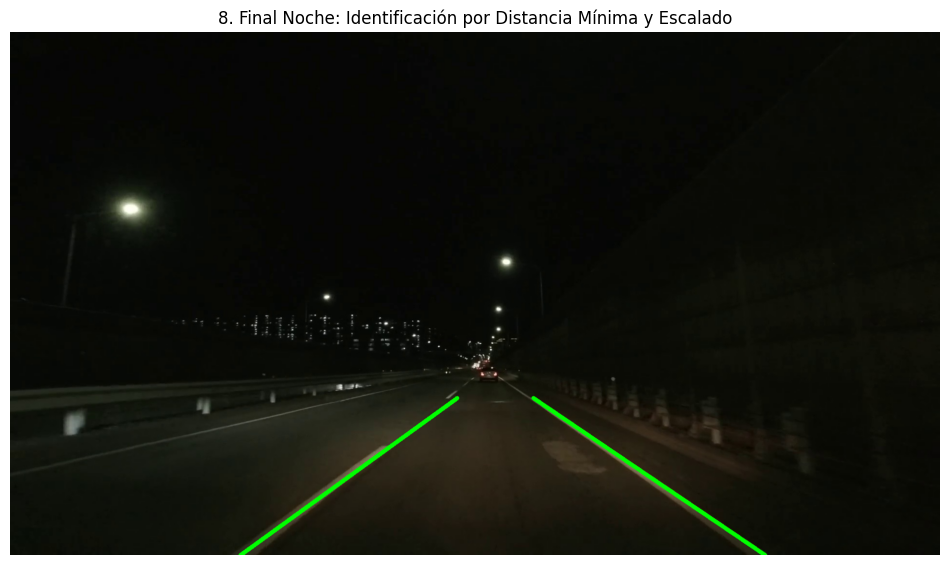

In [14]:
# ==========================================
# 5.3. SELECCIÓN DE CARRILES Y ESCALADO (Eq. 12 a 17)
# ==========================================
import math

# 1. Aplicamos la máscara ROI al mapa binario HSV
alto, ancho = mascara_total.shape
poligono_noche = np.array([[(0, alto), (ancho, alto), 
                            (int(ancho * 0.75), int(alto * 0.6)), 
                            (int(ancho * 0.25), int(alto * 0.6))]])
mask_roi = np.zeros_like(mascara_total)
cv2.fillPoly(mask_roi, poligono_noche, 255)
img_roi_noche = cv2.bitwise_and(mascara_total, mask_roi)

# 2. Transformada de Hough Probabilística
lineas_noche = cv2.HoughLinesP(img_roi_noche, 1, np.pi/180, threshold=20, 
                               minLineLength=15, maxLineGap=200)

centro_x = ancho / 2
candidatos_izq = []
candidatos_der = []

img_final_noche = np.copy(img_noche_rgb)

if lineas_noche is not None:
    for linea in lineas_noche:
        x1, y1, x2, y2 = linea[0]
        if x1 == x2: continue # Evitar divisiones por cero
            
        # --- ECUACIONES 12, 13 y 14 ---
        # Eq 15 & 16: Pendiente e Intersección preliminar
        m_temp = (y2 - y1) / (x2 - x1)
        c_temp = y1 - m_temp * x1
        
        # Eq 12: Ángulo Theta
        theta = abs(math.atan(m_temp))
        
        # Eq 14: Punto medio
        xm = (x1 + x2) / 2 # Suma para coordenada absoluta
        
        # Eq 13: Distancia al centro de la cámara
        d = abs(xm - centro_x)
        
        # Filtrado de ángulo (nos quedamos con líneas entre 20º y 80º aprox)
        if math.radians(20) < theta < math.radians(80):
            if m_temp < 0: # Carril Izquierdo
                candidatos_izq.append({'d': d, 'm': m_temp, 'c': c_temp})
            else:          # Carril Derecho
                candidatos_der.append({'d': d, 'm': m_temp, 'c': c_temp})

# --- SELECCIÓN: "The two closest lines to the frame centre" ---

# Función para escalar la línea ganadora usando Eq. 15, 16 y 17
def dibujar_linea_escalada(candidatos, color):
    if len(candidatos) > 0:
        # Encontramos el diccionario con la distancia 'd' mínima
        mejor_linea = min(candidatos, key=lambda x: x['d'])
        
        m = mejor_linea['m']
        c = mejor_linea['c']
        
        # Eq 17: basecross (Intersección con el eje X cuando Y=0)
        # En coordenadas de imagen Y está invertido, por lo que basecross es el punto de fuga teórico superior.
        basecross = -c / m
        
        # Ajustamos a nuestro horizonte de la cámara (y_horizon = 80% del alto) Calibrar en funcion de la altura de la camara respecto al parachoques
        y_horizon = int(alto * 0.7)
        x_horizon = int((y_horizon - c) / m)
        
        y_bottom = alto
        x_bottom = int((y_bottom - c) / m)
        
        # Dibujamos la línea escalada
        cv2.line(img_final_noche, (x_bottom, y_bottom), (x_horizon, y_horizon), color, 8)

# Aplicamos a cada lado
dibujar_linea_escalada(candidatos_izq, (0, 255, 0)) # Verde
dibujar_linea_escalada(candidatos_der, (0, 255, 0)) # Verde

# Visualización final
plt.figure(figsize=(12, 7))
plt.imshow(img_final_noche)
plt.title("8. Final Noche: Identificación por Distancia Mínima y Escalado")
plt.axis('off')
plt.show()

## 6. Integración del Sistema: Pipeline Dinámico Autónomo

En esta etapa final, consolidamos los diferentes módulos matemáticos y de visión artificial en una arquitectura unificada. Hemos encapsulado las operaciones detalladas en los apartados anteriores dentro de dos funciones principales (`procesar_dia` y `procesar_noche`).

El sistema operará de forma autónoma siguiendo el diagrama de flujo propuesto por los autores:
1. **Evaluación de Iluminación:** Cada fotograma pasa por nuestro sensor matemático para calcular su brillo medio $B$ (Eq. 37).
2. **Enrutamiento Dinámico:** Si $B > 50$, el fotograma se envía al *Pipeline* Diurno. Si $B \leq 50$, se envía al *Pipeline* Nocturno.
3. **Salida:** El sistema devuelve el fotograma con los límites del carril proyectados geométricamente sobre la perspectiva de la vía, adaptándose a las condiciones cambiantes del entorno.

A continuación, seleccionamos el escenario de prueba y ejecutamos el bucle principal (el "guardia de tráfico") sobre una muestra del dataset para validar el comportamiento adaptativo del algoritmo.

In [18]:
# Seleccionamos con qué dataset queremos que trabaje el cuaderno a partir de este punto:

#fotogramas_a_procesar = cargar_secuencia_tusimple(RUTA_TUSIMPLE)
fotogramas_a_procesar = cargar_secuencia_bd2_nocturna(RUTA_NOCTURNA)
#fotogramas_a_procesar = cargar_secuencia_udacity(RUTA_UDACITY, max_frames=500)


BD2 Nocturna cargada: Seleccionado clip 'clip_009' con 20 fotogramas.


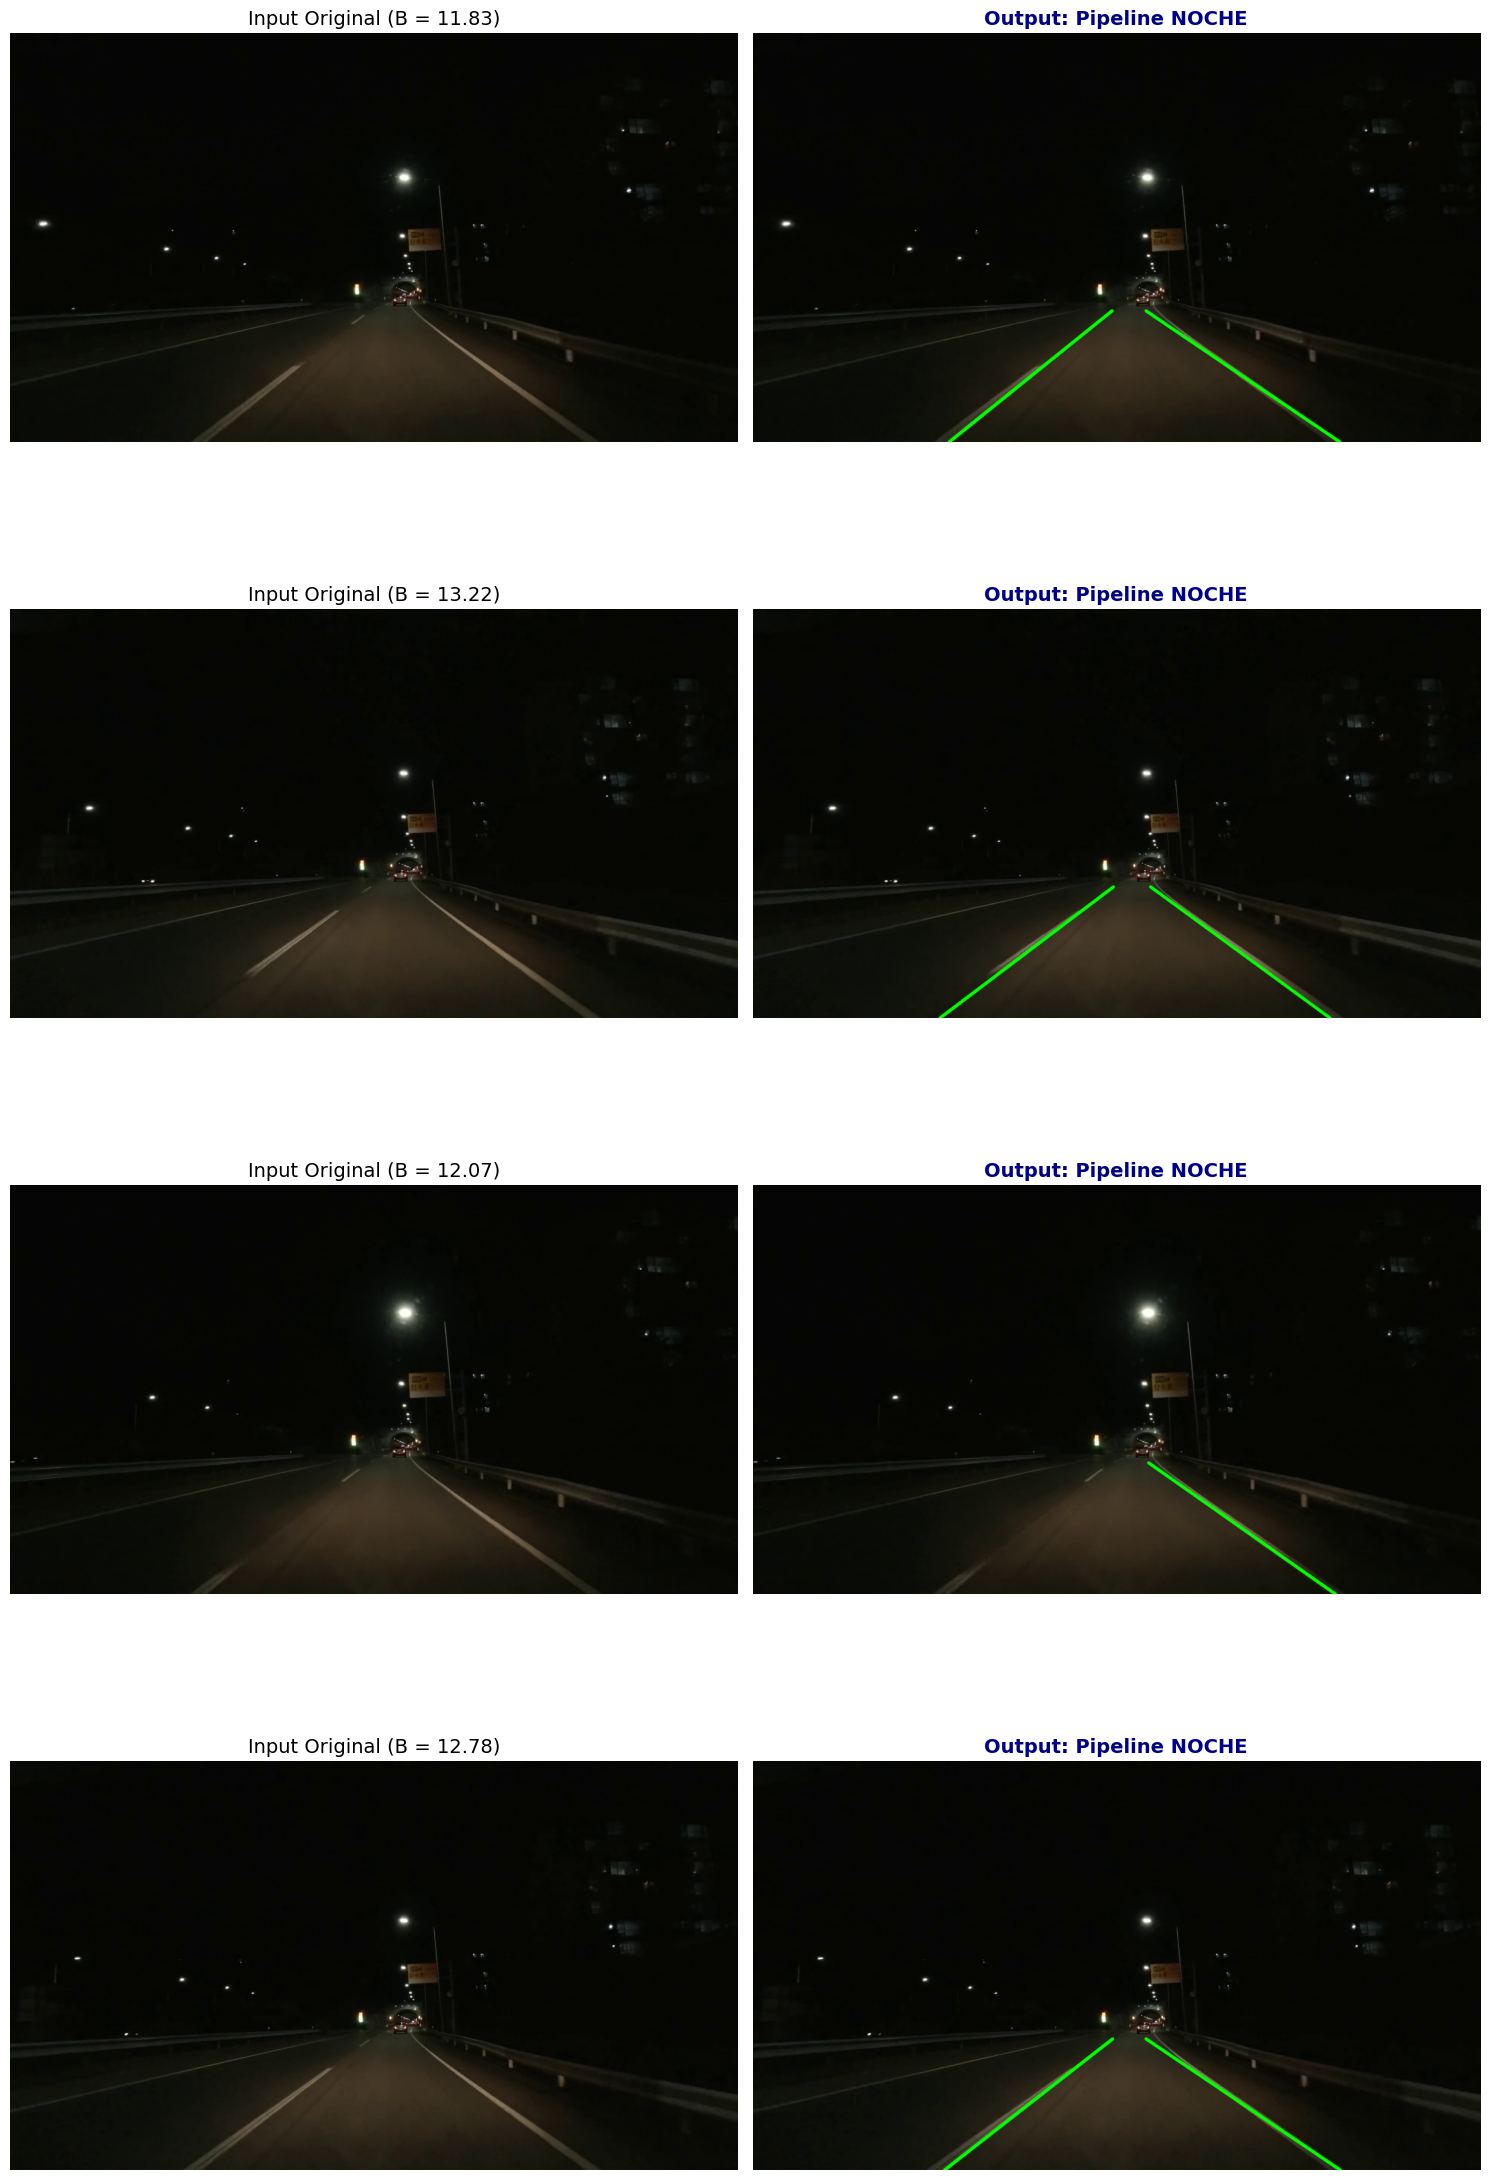

In [19]:
# ---  ENCAPSULACIÓN DE LOS PIPELINES ---
# (Empaquetamos el código de los puntos 4 y 5 para poder llamarlo en bucle)

def procesar_dia(img_bgr):
    alto, ancho = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Preprocesamiento (Filtro Color + Grises + Gaussian)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask_amarillo = cv2.inRange(hsv, np.array([15, 80, 80]), np.array([35, 255, 255]))
    mask_blanco = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 30, 255]))
    img_filtrada = cv2.bitwise_and(img_bgr, img_bgr, mask=cv2.bitwise_or(mask_amarillo, mask_blanco))
    img_blur = cv2.GaussianBlur(cv2.cvtColor(img_filtrada, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    
    # Canny y ROI
    img_canny = cv2.Canny(img_blur, 50, 150)
    poligono = np.array([[(0, alto), (ancho, alto), (int(ancho * 0.65), int(alto * 0.6)), (int(ancho * 0.35), int(alto * 0.6))]])
    mask_roi = np.zeros_like(img_canny)
    cv2.fillPoly(mask_roi, poligono, 255)
    img_roi = cv2.bitwise_and(img_canny, mask_roi)
    
    # Hough y Promediado (Eq. 9 y 10)
    lineas = cv2.HoughLinesP(img_roi, 1, np.pi/180, 20, minLineLength=20, maxLineGap=300)
    p_izq, c_izq, p_der, c_der = [], [], [], []
    
    if lineas is not None:
        for linea in lineas:
            x1, y1, x2, y2 = linea[0]
            if x1 == x2: continue
            slope = (y2 - y1) / (x2 - x1)
            intercept = y1 - slope * x1
            if slope < -0.5:
                p_izq.append(slope); c_izq.append(intercept)
            elif slope > 0.5:
                p_der.append(slope); c_der.append(intercept)

    img_out = np.copy(img_rgb)
    y_min, y_max = int(alto * 0.6), alto
    
    def dibujar(pendientes, interceptos, color):
        if pendientes:
            m = np.mean(pendientes)
            c = np.mean(interceptos)
            cv2.line(img_out, (int((y_max - c)/m), y_max), (int((y_min - c)/m), y_min), color, 8)
            
    dibujar(p_izq, c_izq, (0, 255, 0))
    dibujar(p_der, c_der, (0, 255, 0))
    return img_out


def procesar_noche(img_bgr, y_average):
    alto, ancho = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Gamma Adaptativo (Eq. 18)
    gamma_final = 0.7 - (-0.3 / math.log10(max(y_average, 1e-6)))
    tabla = np.array([((i / 255.0) ** (1.0/gamma_final)) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv2.LUT(img_bgr, tabla)
    
    # HSV Estricto
    hsv = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2HSV)
    mask_blanco = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 25, 255]))
    mask_amarillo = cv2.inRange(hsv, np.array([15, 90, 80]), np.array([35, 255, 255]))
    mask_total = cv2.bitwise_or(mask_blanco, mask_amarillo)
    
    # ROI ajustado por cámara (Horizonte al 68%)
    horizonte = 0.68
    poligono = np.array([[(0, alto), (ancho, alto), (int(ancho * 0.75), int(alto * horizonte)), (int(ancho * 0.25), int(alto * horizonte))]])
    mask_roi = np.zeros_like(mask_total)
    cv2.fillPoly(mask_roi, poligono, 255)
    img_roi = cv2.bitwise_and(mask_total, mask_roi)
    
    # Hough y Distancia Mínima (Eq. 11 a 17)
    lineas = cv2.HoughLinesP(img_roi, 1, np.pi/180, 20, minLineLength=15, maxLineGap=200)
    cand_izq, cand_der = [], []
    centro_x = ancho / 2
    
    if lineas is not None:
        for linea in lineas:
            x1, y1, x2, y2 = linea[0]
            if x1 == x2: continue
            m = (y2 - y1) / (x2 - x1)
            c = y1 - m * x1
            theta = abs(math.atan(m))
            d = abs(((x1 + x2) / 2) - centro_x)
            
            if math.radians(20) < theta < math.radians(80):
                if m < 0: cand_izq.append({'d': d, 'm': m, 'c': c})
                else: cand_der.append({'d': d, 'm': m, 'c': c})

    img_out = np.copy(img_rgb)
    y_min, y_max = int(alto * horizonte), alto
    
    def dibujar_escalado(candidatos, color):
        if candidatos:
            mejor = min(candidatos, key=lambda x: x['d'])
            m, c = mejor['m'], mejor['c']
            cv2.line(img_out, (int((y_max - c)/m), y_max), (int((y_min - c)/m), y_min), color, 8)
            
    dibujar_escalado(cand_izq, (0, 255, 0))
    dibujar_escalado(cand_der, (0, 255, 0))
    return img_out


# --- 3. BUCLE PRINCIPAL AUTÓNOMO ---
if 'fotogramas_a_procesar' in locals() and len(fotogramas_a_procesar) > 0:
    
    # Procesamos una pequeña muestra aleatoria de 4 imágenes para la demostración
    import random
    num_muestras = min(4, len(fotogramas_a_procesar))
    muestras_test = random.sample(fotogramas_a_procesar, num_muestras)
    
    fig, axs = plt.subplots(num_muestras, 2, figsize=(15, 6 * num_muestras))
    if num_muestras == 1: axs = [axs]
        
    for i, ruta in enumerate(muestras_test):
        img_bgr = cv2.imread(ruta)
        if img_bgr is None: continue
        
        # 1. El sensor evalúa la iluminación llamando a la función del Punto 3
        _, brillo, modo = evaluar_iluminacion(img_bgr)
        
        # 2. El algoritmo decide el rumbo
        if modo == "DÍA":
            img_procesada = procesar_dia(img_bgr)
            color_titulo = 'darkorange'
        else:
            img_procesada = procesar_noche(img_bgr, brillo)
            color_titulo = 'darkblue'
            
        # 3. Visualización de los resultados
        img_rgb_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        axs[i][0].imshow(img_rgb_orig)
        axs[i][0].set_title(f"Input Original (B = {brillo:.2f})", fontsize=14)
        axs[i][0].axis('off')
        
        axs[i][1].imshow(img_procesada)
        axs[i][1].set_title(f"Output: Pipeline {modo}", fontsize=14, color=color_titulo, fontweight='bold')
        axs[i][1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ¡Atención! No se han cargado fotogramas. Revisa el selector de dataset superior.")